<center>
<h1 style="font-family:verdana">
🔊 Introducció a les dades d'àudio 🔊

<p> 🎯 <b>Objectiu</b>: En aquesta pràctica repassarem alguns dels conceptes bàsics que hem vist a la teoria sobre les dades d'àudio i el seu preprocessament. </p>


<p> ✨ <b>Contingut</b>: en primer lloc, començarem amb dades sintètiques i aplicarem els conceptes de preprocessament d'àudio vist en teoria. A continuació, farem el mateix preprocessat a un senyal d'àudio real. I finalment, crearem un algorisme que permeta comparar la similitud de diferents àudios, utilitzant les tècniques vistes en teoria. </p>  



<p> ✏ <b>Exercicis</b>: en cada secció anireu trobant exercicis que haureu d'anar resolent. </p>


---

<h2> Índex </h2>

1. [Preprocessament del senyal d'àudio](#section-one)
  * [Exercici 1](#ex-one)
  * [Exercici 2](#ex-two)
  * [Exercici 3](#ex-three)
  * [Exercici 4](#ex-four)
2. [Inspecció i preprocessament del conjunt de dades](#section-two)
  * [Exercici 5](#ex-five)
3. [Identificació del parlant](#section-three)
  * [Exercici 6](#ex-six)

---

In [1]:
!pip install fastdtw
!pip install gdown
!pip install python-Levenshtein

!gdown "https://drive.google.com/uc?id=1-gQ8NlAEqStiXPqqGylDW49ZRUGoo64b"
!tar -zxf recordings.tar.gz

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for fastdtw: filename=fastdtw-0.3.4-py3-none-any.whl size=3630 sha256=3c2a574558f88fe6c403d0f86ddf30914d044b3365125d905be33fce98271a65
  Stored in directory: c:\users\paess\appdata\local\pip\cache\wheels\2c\9e\6d\6c419b5fe1b720cf2f9c7b20ea119dc201878ea890ba26221f
Successfully built fastdtw



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Paess\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Paess\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 369.3 kB/s eta 0:00:03
   ------------- -------------------------- 0.5/1.5 MB 369.3 kB/s eta 0:00:03
   ------------- -------------------------- 0.5/1.5 MB 369.3 kB/s eta 0:00:03
   ------------- -------------------------- 0.5/1.5 MB 369.3 kB/s eta 0:00:03
   ------------- -------------------------- 0.5/1.5 MB 369.3 kB/s eta 0:00:03
   -------------------- ------------------- 0.8/1


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Paess\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
Downloading...
From: https://drive.google.com/uc?id=1-gQ8NlAEqStiXPqqGylDW49ZRUGoo64b
To: c:\Users\Paess\Documents\Uni\TVD\P3\recordings.tar.gz

  0%|          | 0.00/16.0M [00:00<?, ?B/s]
  3%|▎         | 524k/16.0M [00:01<00:39, 389kB/s]
  7%|▋         | 1.05M/16.0M [00:03<00:49, 301kB/s]
 10%|▉         | 1.57M/16.0M [00:05<00:50, 287kB/s]
 13%|█▎        | 2.10M/16.0M [00:05<00:36, 380kB/s]
 16%|█▋        | 2.62M/16.0M [00:06<00:31, 427kB/s]
 20%|█▉        | 3.15M/16.0M [00:07<00:23, 559kB/s]
 23%|██▎       | 3.67M/16.0M [00:07<00:19, 648kB/s]
 26%|██▌       | 4.19M/16.0M [00:08<00:16, 729kB/s]
 29%|██▉       | 4.72M/16.0M [00:08<00:14, 780kB/s]
 33%|███▎      | 5.24M/16.0M [00:09<00:15, 693kB/s]
 36%|███▌      | 5.77M/16.0M [00:10<00:15, 658kB/s]
 39%|███▉      

In [5]:
from IPython.display import Audio
import matplotlib.pyplot as plt
#from fastdtw import fastdtw

import numpy as np
import scipy as sp
import librosa
import librosa.display
import random
import glob
import os

<h1><a name="section-one"> 1. Preprocessament del senyal d'àudio </a></h1>

Per recordar les diferents representacions dels senyals d'àudio que heu vist en teoria començarem amb uns exemples senzills.

En primer lloc, generarem el senyal digital d'un *Do* (C4) i d'un *La* (A4) a partir de dos sinusoides i els reproduirem a continuació.

In [6]:
def generate_signal(frequency, time):
  return np.sin(2 * np.pi * frequency * time)

sample_rate = 44100  # typical for audio
duration = 1  # in seconds
time = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

# C4 (do) note
frequency_c = 261.63 #Hz
c_signal = generate_signal(frequency_c, time)

# A4 (la) note
frequency_a = 440 #Hz
a_signal = generate_signal(frequency_a, time)

In [7]:
Audio(data=c_signal, rate=sample_rate)

In [8]:
Audio(data=a_signal, rate=sample_rate)

A continuació podreu visualitzar les formes de l'ona al domini temporal. Podeu veure com la freqüència de la nota C4 és major que la freqüència de la nota A4.

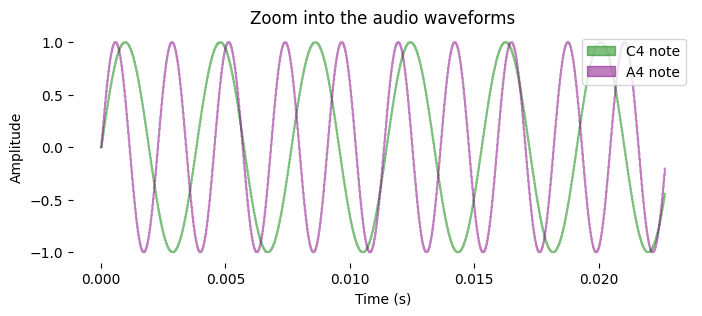

In [9]:
fig, ax = plt.subplots(figsize=(8, 3))
librosa.display.waveshow(c_signal[0:1000], sr=sample_rate, alpha=0.5, color='green', label='C4 note')
librosa.display.waveshow(a_signal[0:1000], sr=sample_rate, alpha=0.5, color='purple', label='A4 note')
plt.title('Zoom into the audio waveforms')
plt.legend(loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

---

 <h1><a name="ex-one"><center> ✏ Exercici 1 ✏</a></h1>

 En aquest primer exercici us demanem que passeu del domini temporal al domini freqüencial. És a dir, que calculeu la Transformada Discreta de Fourier dels dos senyals. Podeu utilitzar qualsevol llibreria com NumPy o SciPy.

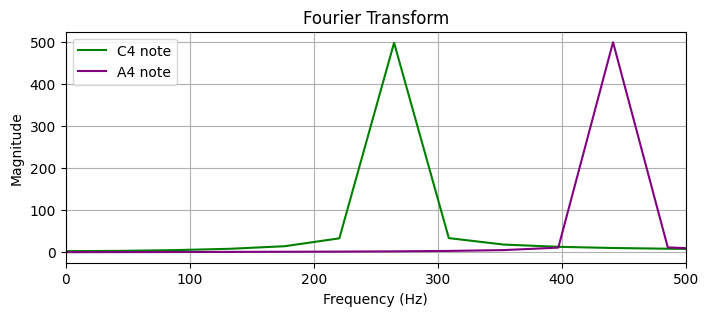

In [10]:
from scipy.fft import fft

#TODO
ft_c = fft(c_signal[0:1000])
ft_a = fft(a_signal[0:1000])

# Plot the magnitude of the Discret Fourier Transform
fig, ax = plt.subplots(figsize=(8, 3))
plt.plot(np.linspace(0, sample_rate, len(np.absolute(ft_c))), np.absolute(ft_c), color='green', label='C4 note')
plt.plot(np.linspace(0, sample_rate, len(np.absolute(ft_a))), np.absolute(ft_a), color='purple', label='A4 note')
plt.title('Fourier Transform')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid()
plt.xlim(0, 500)
plt.legend(loc='upper left')
plt.show()

---

 <h1><a name="ex-two"><center> ✏ Exercici 2 ✏</a></h1>

En aquest segon exercici us demanem que creeu un senyal sumant els dos senyals anteriors. I visualitzeu de nou la forma de l'ona així com la magnitud de la Transformada Discreta de Fourier.

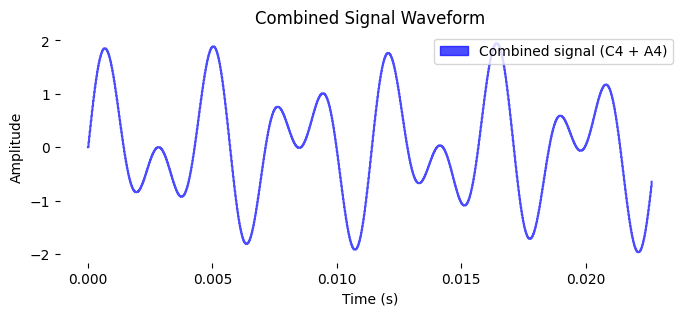

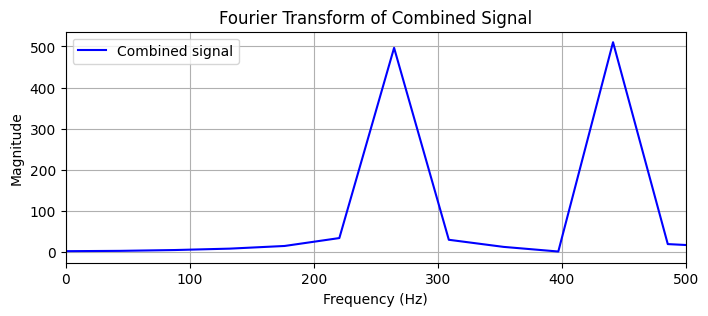

In [11]:
#TODO
# Crear señal combinada sumando las dos señales anteriores
combined_signal = c_signal + a_signal

# Visualizar la forma de onda
fig, ax = plt.subplots(figsize=(8, 3))
librosa.display.waveshow(combined_signal[0:1000], sr=sample_rate, alpha=0.7, color='blue', label='Combined signal (C4 + A4)')
plt.title('Combined Signal Waveform')
plt.legend(loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

# Calcular la Transformada Discreta de Fourier de la señal combinada
ft_combined = fft(combined_signal[0:1000])

# Visualizar la magnitud de la DFT
fig, ax = plt.subplots(figsize=(8, 3))
plt.plot(np.linspace(0, sample_rate, len(np.absolute(ft_combined))), np.absolute(ft_combined), color='blue', label='Combined signal')
plt.title('Fourier Transform of Combined Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid()
plt.xlim(0, 500)
plt.legend(loc='upper left')
plt.show()

---

<h1><a name="ex-three"><center> ✏ Exercici 3 ✏</a></h1>

A continuació us demanem que calculeu l'espectrograma de la senyal combinada que heu calculat abans. Recordeu que l'espectograma és una representació de la variació de les freqüències al llarg del temps.

Per calcular l'espectograma, primer haureu de calcular la STFT. A continuació la magnitud de l'espectre tal i com hem fet amb la DFT. I per últim, haureu de convertir l'epectograma a dB. Recordeu que això és degut al fet que la nostra percepció del so no és lineal, sinó logarítmica. És a dir, no hi ha una relació lineal entre l'amplitud del senyal i com de fort nosaltres la percebem. És per això que mesurem l'amplitud del so en decibels (dB), una escala logarítmica que s'alinea a la nostra percepció de la intensitat. 0dB correspon al so més suau que l'oïda humana pot detectar.


L'espectograma tindrà un tamany de **(n_fft/2 + 1, n_frames)**

- **n_fft** correspon al nombre de punts de cada finestra de la FFT. Per tant quan major siga el paràmetre n_fft major seà la resolució en freqüència. Com en l'STFT només es calcula la meitat positiva de l'espectre de freqüència (ja que és simètrica la part negativa), a l'espectrograma tindrem un total de n_fft/2 + 1.

- **n_frames** correspondrà al nombre de 'particions' en les que s'ha dividit la mostra original d'àudio per a calcular en cada una d'elles l'STFT.
El nombre de períodes de temps dependrà del tamany del audio, del *hop_length* i de la mida de la finestra: `n_frames = 1 + (signal_length - win_length) // hop_length`.


⚡ Podeu utilitzar aquesta [llibreria](https://librosa.org/doc/latest/index.html) de Python

1102 441


C:\Users\Paess\AppData\Local\Temp\ipykernel_10144\1524011939.py:12: UserWarning: Trying to display complex-valued input. Showing magnitude instead.
  librosa.display.specshow(spectrogram, sr=sample_rate, x_axis='time', y_axis='linear', vmin=0)


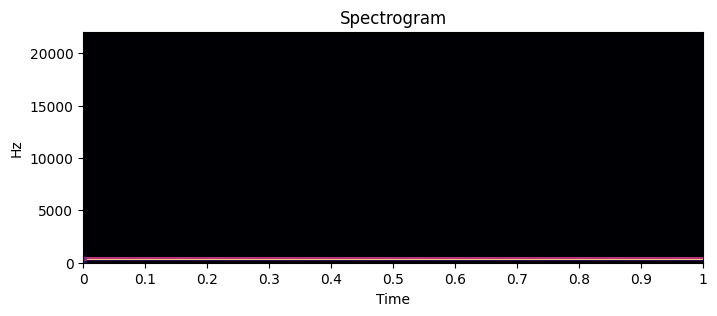

In [12]:
#TODO
import librosa

combined_signal = c_signal + a_signal

frameSize = int(sample_rate * 0.025)
hopSize = int(sample_rate* 0.01)
print(frameSize, hopSize)
spectrogram = librosa.stft(combined_signal, n_fft = frameSize, hop_length = hopSize)

fig, ax = plt.subplots(figsize=(8, 3))
librosa.display.specshow(spectrogram, sr=sample_rate, x_axis='time', y_axis='linear', vmin=0)
ax.set_xlim(0, 1)
plt.title('Spectrogram')
plt.show()

In [ ]:
frameSize

1102


---
<h1><a name="ex-four"><center> ✏ Exercici 4 ✏</a></h1>

Al següent exercici us demanem que calculeu l'espectrograma Mel. Recordeu que la nostra sensibilitat a les freqüències tampoc és lineal, som més sensibles a les freqüències entre 2kHz i 5kHz i menys sensibles a freqüències molt baixes (infrasons) o molt altes (ultrasons). Per aquest motiu, en el processament d'àudio, s'utilitza una escala no lineal, anomenada escala Mel, que simula com els humans percebem els canvis de to.

Recordeu que per caclular l'espectrograma Mel primer (tal i com hem fet abans) haureu de calcular la SFTF, a continuació convertir les amplituds a dB i, finalment, convertir les freqüències a l'escala Mel. Amb la llibreria *librosa* es pot calcular directament `librosa.feature.melspectrogram(y=y, sr=sr)`, però a aquest exercici us demanem que ho calculeu a partir dels filtres Mel.

A continuació, us proporcionem ja el codi per obtenir els filtres Mel.


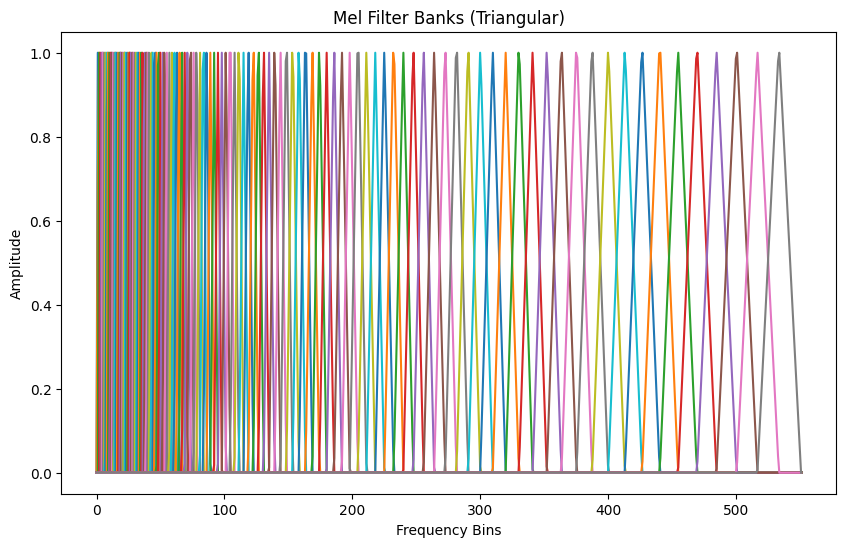

In [13]:
mel_filter_bank = librosa.filters.mel(sr=sample_rate, n_fft=frameSize, n_mels=128)
mel_filter_bank_normalized = mel_filter_bank/np.max(mel_filter_bank, axis=1, keepdims=True)

plt.figure(figsize=(10, 6))
for i, filter_i in enumerate(mel_filter_bank_normalized):
  plt.plot(np.arange(len(filter_i)), filter_i, label=f'Filter {i+1}')

plt.title('Mel Filter Banks (Triangular)')
plt.xlabel('Frequency Bins')
plt.ylabel('Amplitude')
plt.show()

Mel filter bank shape:  (128, 552)


C:\Users\Paess\AppData\Local\Temp\ipykernel_10144\483115552.py:8: UserWarning: Trying to display complex-valued input. Showing magnitude instead.
  librosa.display.specshow(mel_spectrogram, sr=sample_rate, x_axis='time', y_axis='mel', vmin=0);


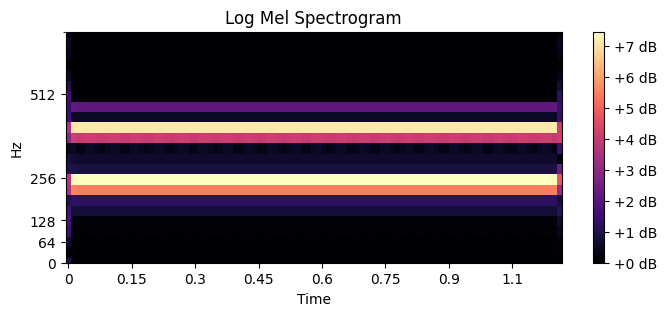

In [14]:
#TODO
spectrogram = librosa.stft(combined_signal, n_fft = frameSize, hop_length = hopSize)
print('Mel filter bank shape: ', mel_filter_bank.shape)

mel_spectrogram = np.dot(mel_filter_bank, spectrogram)

fig, ax = plt.subplots(figsize=(8, 3))
librosa.display.specshow(mel_spectrogram, sr=sample_rate, x_axis='time', y_axis='mel', vmin=0);
plt.colorbar(format='%+2.0f dB')
ax.set_ylim(0, 700)
y_ticks = [0, 64, 128, 256, 512]
ax.set_yticks(y_ticks)
plt.title('Log Mel Spectrogram')
plt.show()

---
Finalment, si volguérem calcular els Mel-Frequency Spectral Coefficients només ens quedaria computar la Transformada Discreta del Cosinus. Per sort, gràcies a la llibreria librosa, amb només una línia de codi podem calcular aquests coeficients.

`librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)`

<h1><a name="section-two"> 2. Inspecció i preprocessament del conjunt de dades </a></h1>

Ara que ja hem jugat amb uns senyals d'àudio sintètics, passarem a treballar amb dades d'àudio reals. El conjunt de dades que farem servir en aquesta pràctica el podeu trobar [aquí](https://github.com/Jakobovski/free-spoken-digit-dataset). Consta de 3.000 enregistraments on s'escolten els 9 dígits. Hi ha un total de 6 parlants amb diferents pronunciacions i 50 mostres per cada parell de dígit-parlant.


⏯ A continuació podreu escoltar alguns exemples.

In [ ]:
Audio('recordings/0_george_4.wav', autoplay=True)

In [ ]:
Audio('recordings/0_lucas_0.wav', autoplay=True)

In [ ]:
Audio('recordings/8_nicolas_0.wav', autoplay=True)

In [ ]:
Audio('recordings/8_jackson_0.wav', autoplay=True)

---

<h1><a name="ex-five"><center> ✏ Exercici 5 ✏</a></h1>

Tal i com hem fet amb les dades sintètiques, en aquest exercici us demanem que:

1. Visualitzeu l'ona (*waveform*) d'una de les mostres. Per visualitzar-la necessitareu tant el senyal d'àudio (y), com la freqüència de mostreig o *sampling rate* en anglès (sr). Recordeu que la freqüència de mostreig indica quantes mostres es prenenen per segon.
2. Visualitzeu el Log-Amplitud Spectrogram.
3. Visualitzeu el Mel Spectrogram.

In [ ]:
recordings_path = 'recordings'
records_list = glob.glob(os.path.join(recordings_path, "*"))
random_number = random.randint(0, len(records_list))
y, sr = librosa.load(records_list[random_number])
frameSize = int(sr * 0.025)
hopSize =int(sr * 0.01)

Audio(records_list[random_number], autoplay=True)

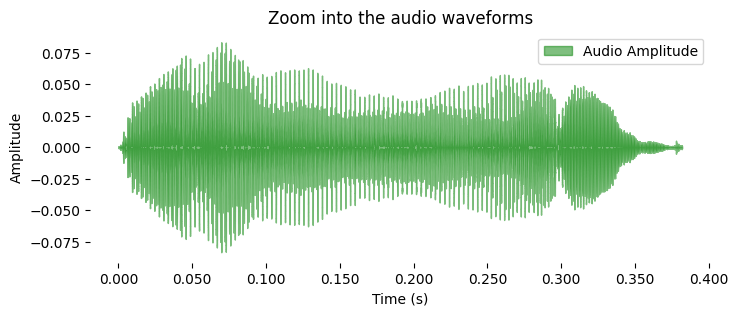

In [ ]:
#TODO
def plot_waveform(audio, sr):
  fig, ax = plt.subplots(figsize=(8, 3))
  librosa.display.waveshow(y, sr=sample_rate, alpha=0.5, color='green', label='Audio Amplitude')
  plt.title('Zoom into the audio waveforms')
  plt.legend(loc='upper right')
  ax.spines['top'].set_visible(False)
  ax.spines['right'].set_visible(False)
  ax.spines['bottom'].set_visible(False)
  ax.spines['left'].set_visible(False)
  plt.xlabel('Time (s)')
  plt.ylabel('Amplitude')
  plt.show()

plot_waveform(y,sr)

---



/tmp/ipython-input-714354374.py:3: UserWarning: power_to_db was called on complex input so phase information will be discarded. To suppress this warning, call power_to_db(np.abs(D)**2) instead.
  spectrogram_db = librosa.power_to_db(spectrogram);


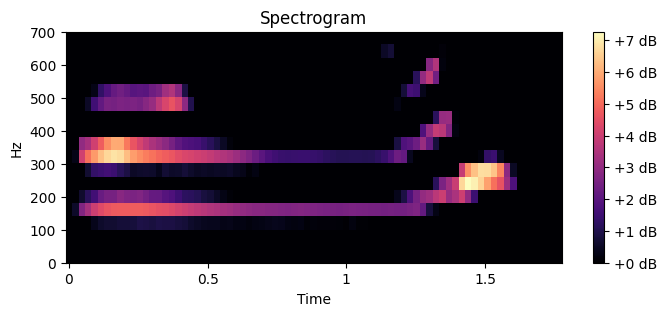

In [ ]:
def plot_spectrogram(y, sample_rate, frameSize, hopSize):
  spectrogram = librosa.stft(y,   n_fft = frameSize, hop_length = hopSize)
  spectrogram_db = librosa.power_to_db(spectrogram);
  fig, ax = plt.subplots(figsize=(8, 3))
  librosa.display.specshow(spectrogram_db, sr=sample_rate, x_axis='time', y_axis='linear', vmin=0);
  plt.colorbar(format='%+2.0f dB')
  ax.set_ylim(0, 700)
  plt.title('Spectrogram')
  plt.show()

plot_spectrogram(y, sr, frameSize, hopSize)


/tmp/ipython-input-545481554.py:10: UserWarning: Trying to display complex-valued input. Showing magnitude instead.
  librosa.display.specshow(mel_spectrogram, sr=sample_rate)


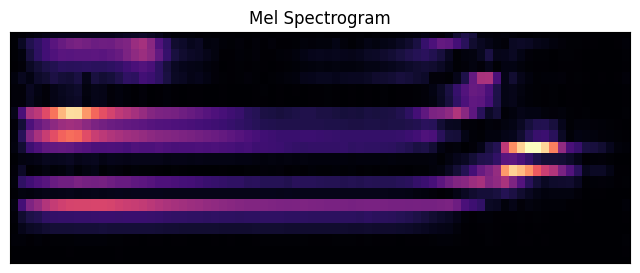

In [ ]:
def plot_mel_spectrogram(y, sample_rate, frameSize, hopSize):
  spectrogram = librosa.stft(y,  n_fft = frameSize, hop_length = hopSize,)

  mel_filter_bank = librosa.filters.mel(sr=sample_rate, n_fft=frameSize, n_mels=128, fmin=0.0, fmax=sr/2)
  mel_filter_bank_normalized = mel_filter_bank/np.max(mel_filter_bank, axis=1, keepdims=True)

  mel_spectrogram = np.dot(mel_filter_bank, spectrogram)
  fig, ax = plt.subplots(figsize=(8, 3))
  ax.set_ylim(0, 20)
  librosa.display.specshow(mel_spectrogram, sr=sample_rate)
  plt.title('Mel Spectrogram')
  plt.show()

plot_mel_spectrogram(y, sr, frameSize, hopSize)

<h1><a name="section-three"> 3. Identificació del parlant </a></h1>

En aquesta última part us proporcionem un codi senzill per comparar e identificar la similitud dels àudios del mateix dígit d'un mateix parlant respecte a la resta. És a dir, donat un àudio d'un dígit i un parlant concret, buscarem (només d'entre els àudios del mateix dígit) aquells àudios que corresponen al mateix parlant i dígit.

Per a comparar les diferents senyals d'àudio utilitzarem els Mel-Frequency Cesptral Coefficients (MFCC) i els compararem utilizant la distància DTW (Dynamic Time Warping). Recordeu que aquesta distància s'utilitza per mesurar la similitud entre dues seqüències que poden tenir variacions temporals fent servir la següent formula:

```
cost := d(s[i], t[j])
DTW[i, j] := cost + minimum(DTW[i-1, j  ],    
                            DTW[i  , j-1],    
                            DTW[i-1, j-1])   
```

In [ ]:
recordings_path = 'recordings'
records_list = glob.glob(os.path.join(recordings_path, "*"))

records_per_digit = {}
for record in records_list:
  digit = int(record.split('_')[0].split('/')[1])
  if digit not in records_per_digit:
    records_per_digit[digit] = [record]
  else:
    records_per_digit[digit].append(record)

Podeu triar el dígit que vulgueu, simplement canvieu el valor de `digit` 🎲.

In [ ]:
digit = 5
records = records_per_digit[digit]
audio_path_ref = records[0]
records.pop(0)
print('Audio ref: ', audio_path_ref)
print('List of audios (same number as ref): ', records)

Audio ref:  recordings/5_george_36.wav
List of audios (same number as ref):  ['recordings/5_yweweler_11.wav', 'recordings/5_nicolas_27.wav', 'recordings/5_george_43.wav', 'recordings/5_jackson_21.wav', 'recordings/5_george_33.wav', 'recordings/5_theo_21.wav', 'recordings/5_jackson_32.wav', 'recordings/5_jackson_1.wav', 'recordings/5_george_31.wav', 'recordings/5_jackson_37.wav', 'recordings/5_nicolas_44.wav', 'recordings/5_nicolas_42.wav', 'recordings/5_yweweler_6.wav', 'recordings/5_george_48.wav', 'recordings/5_jackson_35.wav', 'recordings/5_lucas_17.wav', 'recordings/5_nicolas_7.wav', 'recordings/5_nicolas_4.wav', 'recordings/5_lucas_37.wav', 'recordings/5_theo_43.wav', 'recordings/5_yweweler_35.wav', 'recordings/5_yweweler_22.wav', 'recordings/5_theo_26.wav', 'recordings/5_theo_39.wav', 'recordings/5_lucas_38.wav', 'recordings/5_yweweler_12.wav', 'recordings/5_jackson_48.wav', 'recordings/5_nicolas_2.wav', 'recordings/5_lucas_3.wav', 'recordings/5_jackson_7.wav', 'recordings/5_nico

In [ ]:
from fastdtw import fastdtw

incorrect = 0
correct = 0

def compute_mfcc(audio_path, n_mfcc=13):
    y, sr = librosa.load(audio_path)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return mfccs


def calculate_dtw_distance(mfccs1, mfccs2):
    distance, _ = fastdtw(mfccs1.T, mfccs2.T)
    return distance

for record in records:
  mfccs_ref = compute_mfcc(audio_path_ref)
  mfccs = compute_mfcc(record)

  dtw_distance = calculate_dtw_distance(mfccs_ref, mfccs)

  similarity_threshold = 3000

  if dtw_distance < similarity_threshold:

      if record.split('_')[1] == audio_path_ref.split('_')[1]:
        correct += 1
      else:
        incorrect +=1

print(f'{correct} audios from {record.split("_")[1]} correctly identified')
print(f'{incorrect} audios incorrectly identified')

31 audios from george correctly identified
0 audios incorrectly identified


---